In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [4]:
# Load Dataset
df = pd.read_csv("Boston (1).csv")

In [5]:
# Display First 5 Rows
print("First 5 Rows:\n")
print(df.head())

First 5 Rows:

   Unnamed: 0     crim    zn  indus  chas    nox     rm   age     dis  rad  \
0           1  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1   
1           2  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2   
2           3  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2   
3           4  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3   
4           5  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3   

   tax  ptratio   black  lstat  medv  
0  296     15.3  396.90   4.98  24.0  
1  242     17.8  396.90   9.14  21.6  
2  242     17.8  392.83   4.03  34.7  
3  222     18.7  394.63   2.94  33.4  
4  222     18.7  396.90   5.33  36.2  


In [7]:
# Remove Unnecessary Column if Present
if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)

In [8]:
# Dataset Information
print("\nDataset Info:\n")
print(df.info())


Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  black    506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB
None


In [9]:
# Statistical Summary
print("\nStatistical Summary:\n")
print(df.describe())


Statistical Summary:

             crim          zn       indus        chas         nox          rm  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean     3.613524   11.363636   11.136779    0.069170    0.554695    6.284634   
std      8.601545   23.322453    6.860353    0.253994    0.115878    0.702617   
min      0.006320    0.000000    0.460000    0.000000    0.385000    3.561000   
25%      0.082045    0.000000    5.190000    0.000000    0.449000    5.885500   
50%      0.256510    0.000000    9.690000    0.000000    0.538000    6.208500   
75%      3.677083   12.500000   18.100000    0.000000    0.624000    6.623500   
max     88.976200  100.000000   27.740000    1.000000    0.871000    8.780000   

              age         dis         rad         tax     ptratio       black  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean    68.574901    3.795043    9.549407  408.237154   18.455534  356.674032   
std 

In [10]:
# Shape of Dataset
print("\nDataset Shape:", df.shape)

# Column Names
print("\nColumns:\n")
print(df.columns)

# Check Missing Values
print("\nMissing Values:\n")
print(df.isnull().sum())




Dataset Shape: (506, 14)

Columns:

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'black', 'lstat', 'medv'],
      dtype='object')

Missing Values:

crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
black      0
lstat      0
medv       0
dtype: int64


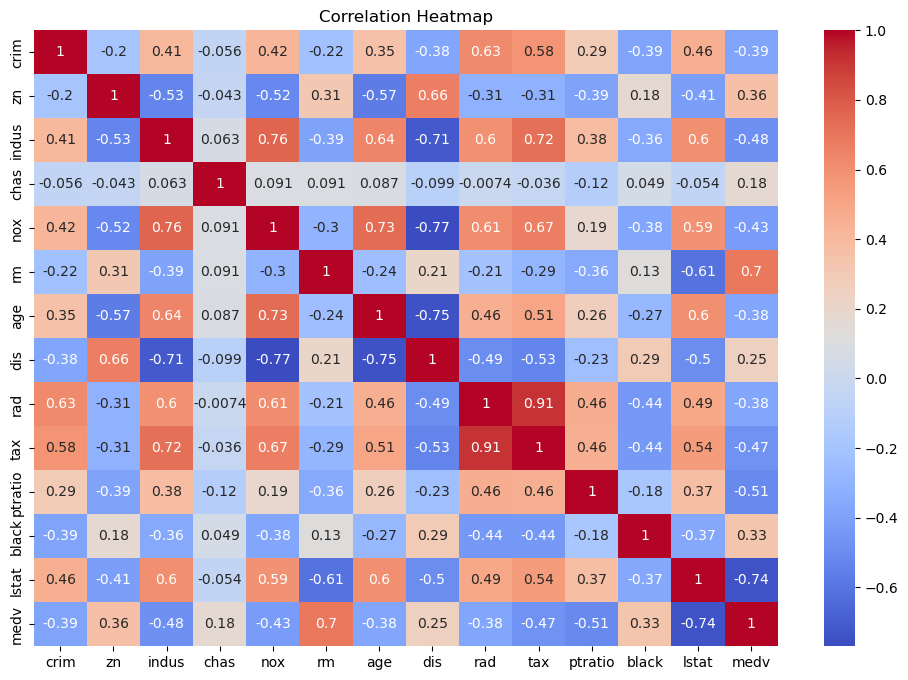

In [11]:
# Correlation Heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()


In [12]:

# Split Features and Target
X = df.drop('medv', axis=1)

y = df['medv']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
# Display Shapes
print("\nTraining Feature Shape:", X_train.shape)
print("Testing Feature Shape:", X_test.shape)


Training Feature Shape: (404, 13)
Testing Feature Shape: (102, 13)


In [14]:
# Create Model
model = LinearRegression()

# Train Model
model.fit(X_train, y_train)

# Coefficients
print("\nModel Coefficients:\n")
print(model.coef_)

# Intercept
print("\nModel Intercept:\n")
print(model.intercept_)


Model Coefficients:

[-1.13055924e-01  3.01104641e-02  4.03807204e-02  2.78443820e+00
 -1.72026334e+01  4.43883520e+00 -6.29636221e-03 -1.44786537e+00
  2.62429736e-01 -1.06467863e-02 -9.15456240e-01  1.23513347e-02
 -5.08571424e-01]

Model Intercept:

30.246750993924394


In [15]:
# Predictions
y_train_pred = model.predict(X_train)

y_test_pred = model.predict(X_test)

# Create Result DataFrame
result = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_test_pred
})

print("\nActual vs Predicted:\n")
print(result.head())


Actual vs Predicted:

     Actual Price  Predicted Price
173          23.6        28.996724
274          32.4        36.025565
491          13.6        14.816944
72           22.8        25.031979
452          16.1        18.769880


In [16]:
# Evaluation Metrics
mse = mean_squared_error(y_test, y_test_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_test_pred)

print("\nModel Evaluation:\n")
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R2 Score:", r2)


Model Evaluation:

Mean Squared Error (MSE): 24.29111947497345
Root Mean Squared Error (RMSE): 4.92860218266533
R2 Score: 0.6687594935356329


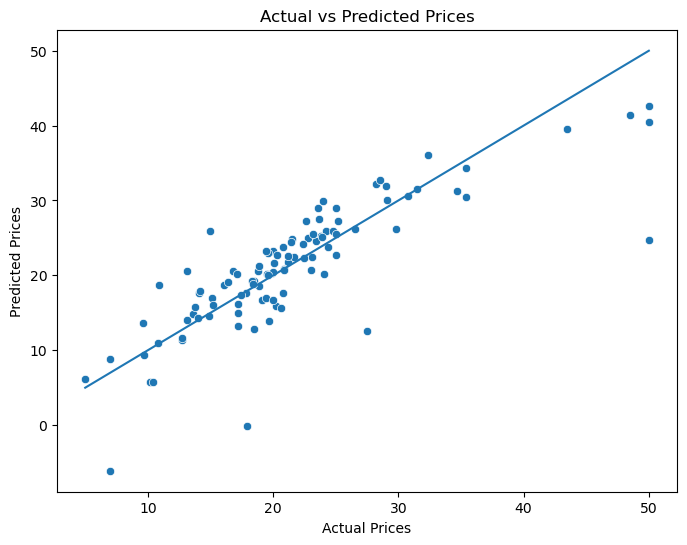

In [17]:
# Actual vs Predicted Plot
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=y_test,
    y=y_test_pred
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual Prices")

plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted Prices")

plt.show()

In [1]:
value = [[6.5]]

prediction = model.predict(value)

print(prediction)

NameError: name 'model' is not defined